In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re

In [2]:
out_dir = '.'
devices = ['cpu', 'gpu_h200']

# Format: (marker, color, label)
SOLVERS = ['dq_basic', 'cayley']
solver_style = {
    'dq_basic': ('s', '#2a78d6', 'Basic (Dynamiqs)'),
    'cayley'  : ('^', '#008300', 'Cayley (Dynamiqs)')
}

# Read the data
data = {}
for device in devices:
    data[device] = np.load(f'{out_dir}/{device}.npy', allow_pickle=True).item()

In [3]:
def collect(data_for_method, key='', avg_type='median', breakdown=False):
    """ Collect stats for a given key. """
    if not key:
        return np.array([]), np.array([]), np.array([])

    dims = sorted(data_for_method.keys())
    avg_func = np.median if avg_type == 'median' else np.mean
    valid_dims, avgs, all_values = [], [], []
    
    for d in dims:
        # skip dims that don't have any data
        if d not in data_for_method:
            continue

        # Get the values
        if breakdown:
            vals = [row['device_op_ns'][key] for row in data_for_method[d]]
        else:
            vals = [row[key] for row in data_for_method[d]]
        valid_dims.append(d)
        avgs.append(avg_func(vals))
        all_values.append(vals)
    return np.array(valid_dims), np.array(avgs), np.array(all_values)

def collect_breakdown(data_for_method, avg_type='mean', top_n=7):
    """ Collect stats for all keys in the 'device_op_ns' breakdown. """
    
    dims = sorted(data_for_method.keys())
    
    per_dim = []
    totals = {}
    for d in dims:
        rows = data_for_method[d]
        
        # go through all the runs (time stored in ms)
        mean_wall_time = {}
        for r in rows:
            for op, time in r['device_op_ns'].items():
                op_key = re.sub(r'\.\d+$', '', op)
                mean_wall_time[op_key] = mean_wall_time.get(op_key, 0.0) + time / len(rows) / 1e6
        per_dim.append(mean_wall_time)
        
        # add up the time across dimensions
        for op_key, time in mean_wall_time.items():
            totals[op_key] = totals.get(op_key, 0.0) + time

    # get the top_n operations by total time
    top = [op for op, _ in sorted(totals.items(), key=lambda kv: kv[1], reverse=True)[:top_n]]

    # essentially, transpose to get time vs. dim for each op
    table = {op: np.array([d.get(op, 0.0) for d in per_dim]) for op in top}

    # get the "other" category, which is the sum of all ops not in the top_n
    table['other'] = np.array([sum(v for k, v in d.items() if k not in top) for d in per_dim])

    return dims, table

def any_row_has_key(runs_by_method, key):
    return any(
        key in row
        for data_for_method in runs_by_method.values()
        for rows in data_for_method.values()
        for row in rows
    )

# Plot runtime and memory consumption

In [4]:
def plot_series(ax, d_arr, avgs, all_values, marker, label, color, linestyle='-', alpha=1):
    if len(d_arr) == 0:
        return
    line, = ax.plot(d_arr, avgs, marker=marker, linestyle=linestyle, label=label, 
                    color=color, alpha=alpha)
    for d, vals in zip(d_arr, all_values):
        ax.scatter([d] * len(vals), vals, marker=marker, color=color, alpha=0.25, s=15, zorder=3)

def style_axis(ax, dims, title, ylabel, fontsize):
    ax.set_xlabel('Dimension $d$', fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xticks(dims)
    ax.set_xticklabels(dims, rotation=45, ha='right')
    ax.tick_params(axis='both', labelsize=fontsize)
    ax.set_title(title, fontsize=fontsize)

def plot_compare_runs(device_data, suptitle="", figsize=(6*2.5, (3/4)*6*2), fontsize=12):

    fig, axs = plt.subplots(1, 3, figsize=(6*3, (3/4)*6), constrained_layout=True)
    axs = axs.flatten()

    panels = [
        (axs[0], 't_total',   'Time (s)',          'Wall time vs. dimension'),
        (axs[1], 'mem_total', 'Memory Host (MB)',  'Memory Host vs. dimension'),
        (axs[2], 'mem_gpu',   'Memory GPU (MB)',   'Memory GPU vs. dimension'),
    ]

    # For each panel
    for ax, key, ylabel, title in panels:

        # skip if no runs have this key
        if not any_row_has_key(device_data, key):
            ax.text(0.5, 0.5, f'{key} not found in any runs',
                 ha='center', va='center', 
                 transform=ax.transAxes, color='gray', fontsize=fontsize)
        
        # if found, plot the data for each method
        else:
            for method, (marker, color, label) in solver_style.items():
                dims, avgs, data = collect(device_data[method], key)
                plot_series(ax, dims, avgs, data, marker=marker, color=color, label=label)

        # style
        style_axis(ax, dims, title, ylabel, fontsize)

    # All subplots share the same method legend; show it once to the right of the figure.
    handles, labels = [], []
    for ax in axs:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    fig.legend(handles, labels, loc='outside right center', fontsize=fontsize)

    if suptitle:
        fig.suptitle(suptitle, fontsize=1.5*fontsize)
    
    plt.show()

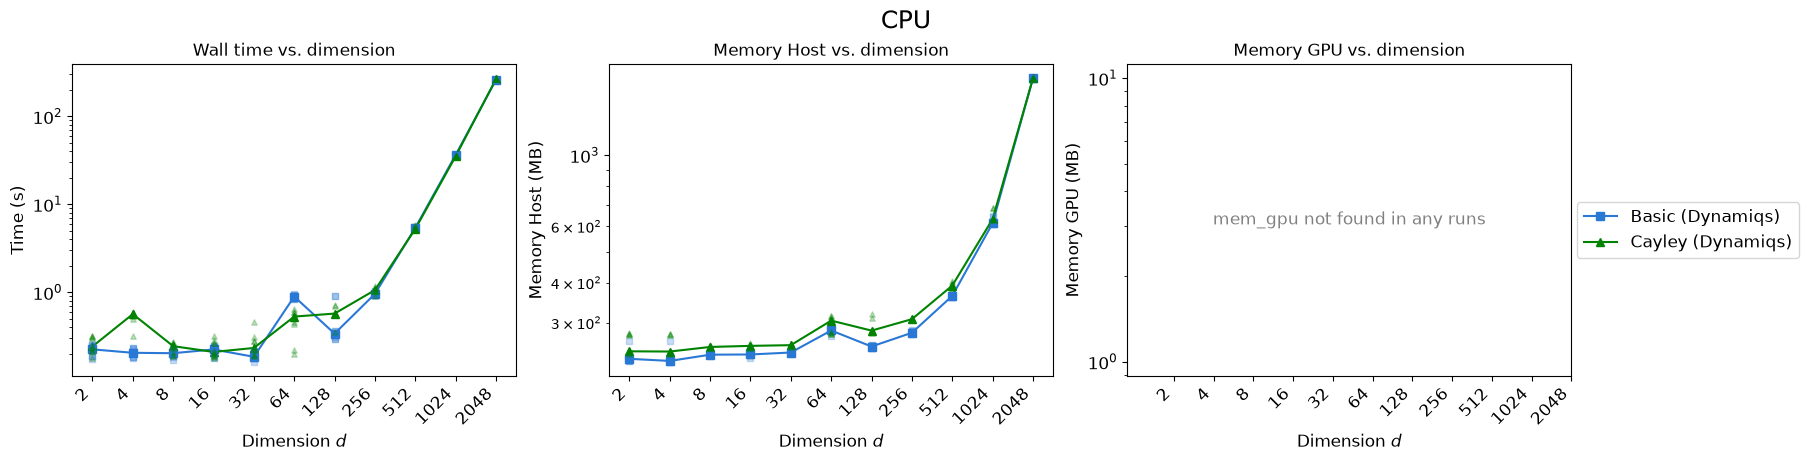

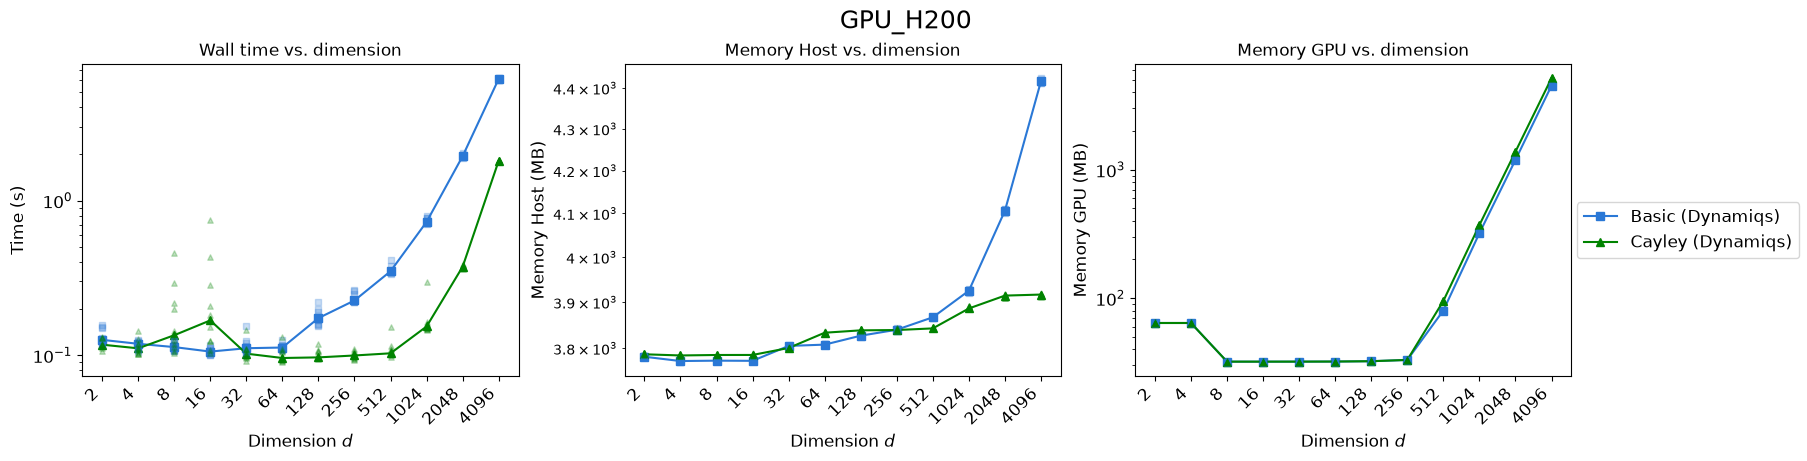

In [5]:
for device in devices:
    plot_compare_runs(data[device], suptitle=f'{device.upper()}')

## Bottleneck breakdown by HLO op category

In [6]:
def plot_breakdown(data_for_device, suptitle="", fontsize=12, normalize=False, 
                   top_n=7, without_command_buffer=False):

    # OP_COLORS = ['#2a78d6', '#008300', '#e87ba4', '#eda100',
    #             '#1baf7a', '#eb6834', '#4a3aa7']
    OP_COLORS = [
        v for k, v in mcolors.TABLEAU_COLORS.items() if k != 'tab:gray'
    ]
    OTHER_COLOR = '#9c9b93'

    fig, axs = plt.subplots(1, len(SOLVERS), 
                            figsize=(6 * len(SOLVERS), 4.5), sharey=False, 
                            constrained_layout=True)
    if len(SOLVERS) == 1:
        axs = [axs]

    for ax, solver in zip(axs, SOLVERS):
        dims, table = collect_breakdown(data_for_device[solver], top_n=top_n)
        x = np.arange(len(dims))
        
        # stacked bar chart (make sure 'other' is last)
        bottom = np.zeros(len(dims))
        ops = [op for op in table 
                if op != 'other' and (
                    not op.startswith('command_buffer') or not without_command_buffer
                )]
        ops += ['other']
        # cycle colors so the list always matches len(ops), even if top_n exceeds len(OP_COLORS)
        colors = [OP_COLORS[i % len(OP_COLORS)] for i in range(len(ops) - 1)] + [OTHER_COLOR]

        # total only over the ops actually being plotted, so normalized shares add up to 100%
        totals = sum(table[op] for op in ops)

        for op, c in zip(ops, colors):
            if normalize:
                share = np.divide(table[op], totals, out=np.zeros_like(totals), where=totals > 0) * 100
            else:
                share = table[op]

            ax.bar(x, share, bottom=bottom, width=0.7, color=c, label=op, 
                   edgecolor='white', linewidth=0.5)
            bottom += share

        ax.set_xlabel('Dimension $d$', fontsize=fontsize)
        ax.set_xticks(x)
        ax.set_xticklabels(dims, rotation=45, ha='right')
        ax.tick_params(axis='both', labelsize=fontsize)
        ax.set_title(solver, fontsize=fontsize)
        ax.legend(fontsize=fontsize, loc='upper left')
        ax.grid(True, axis='y', alpha=0.4)

    if normalize:
        axs[0].set_ylabel('Device time (%)', fontsize=fontsize)
    else:
        axs[0].set_ylabel('Device time (ms)', fontsize=fontsize)

    if suptitle:
        fig.suptitle(suptitle, fontsize=1.5*fontsize)

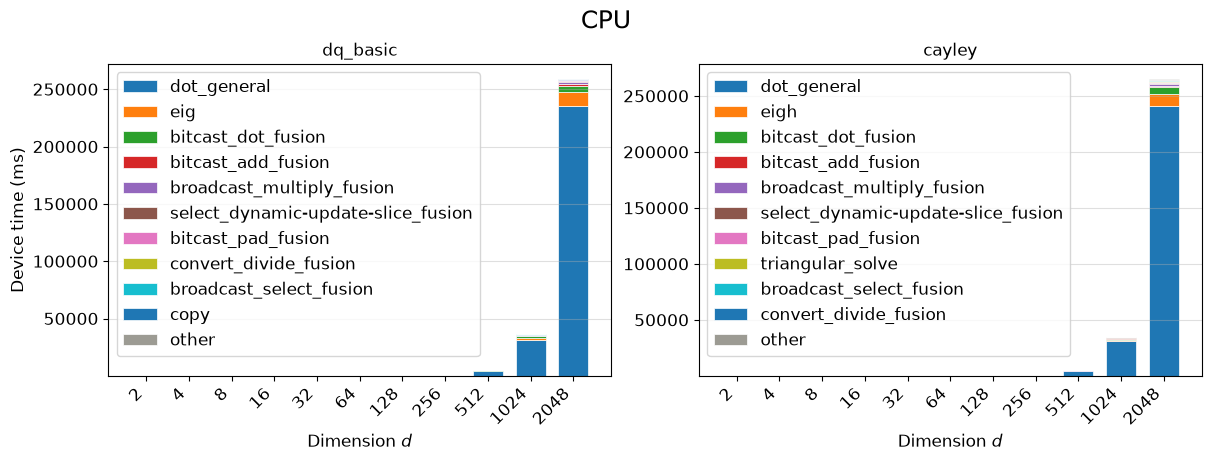

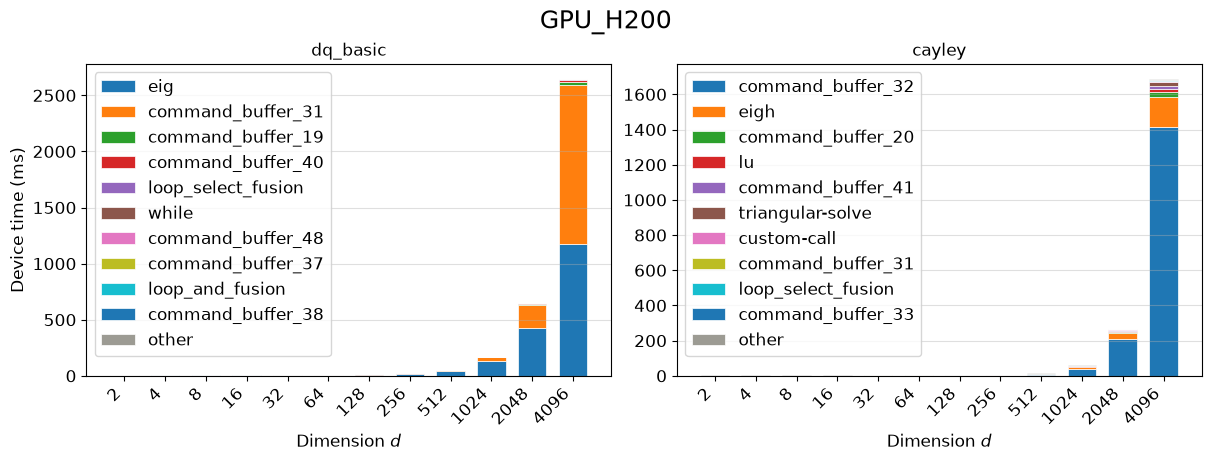

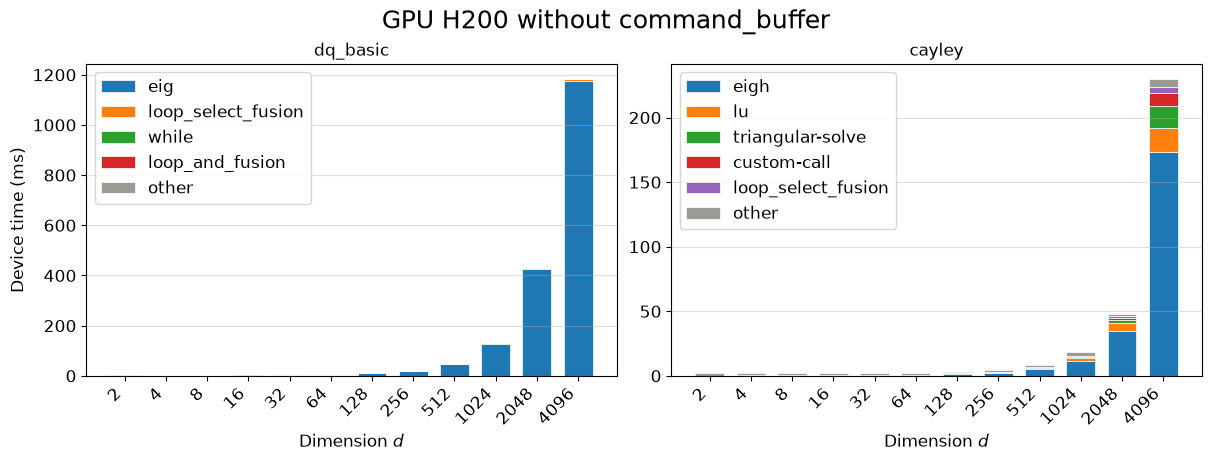

In [7]:
for device in devices:
    plot_breakdown(data[device], suptitle=f'{device.upper()}', top_n=10)

plot_breakdown(data['gpu_h200'], suptitle=f'GPU H200 without command_buffer', top_n=10, 
                without_command_buffer=True)

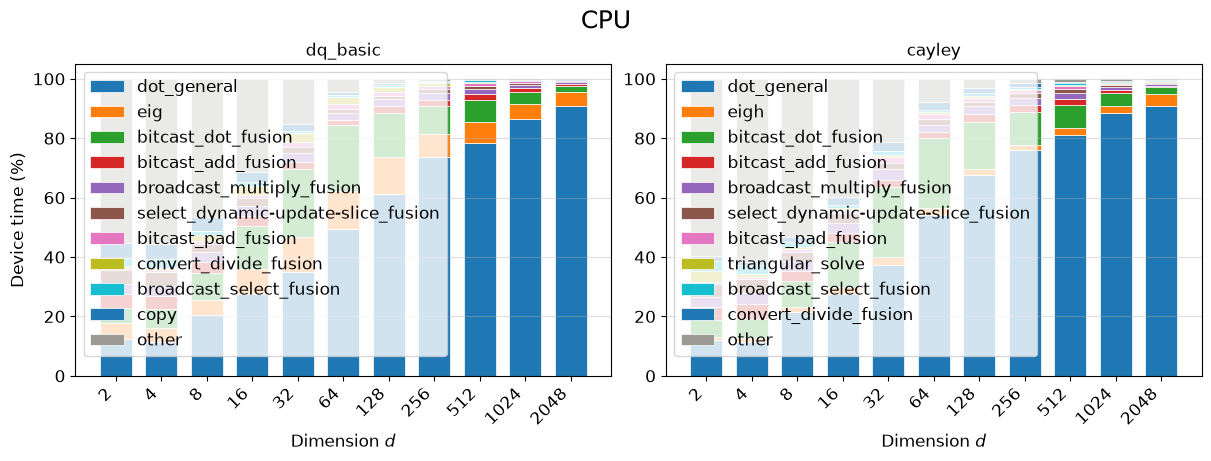

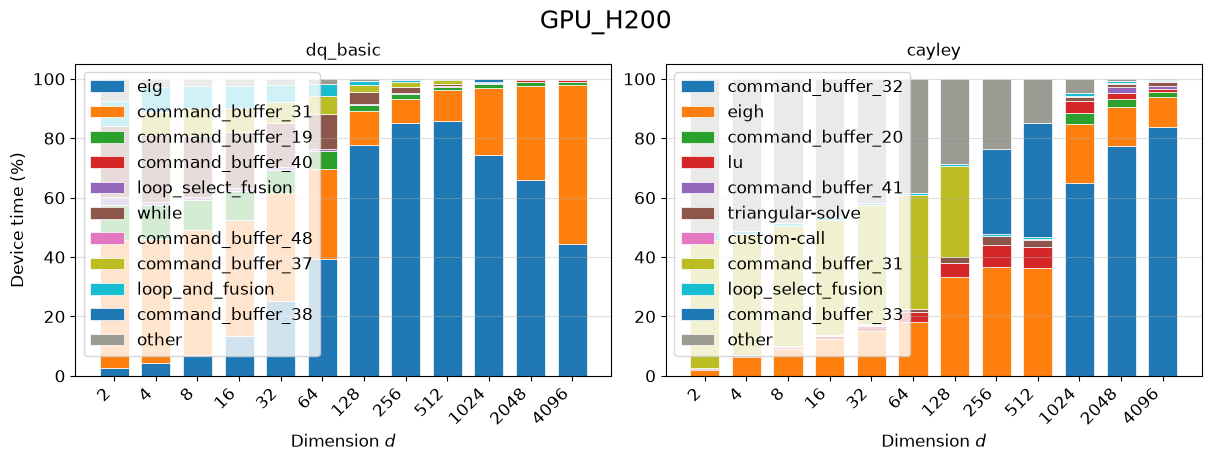

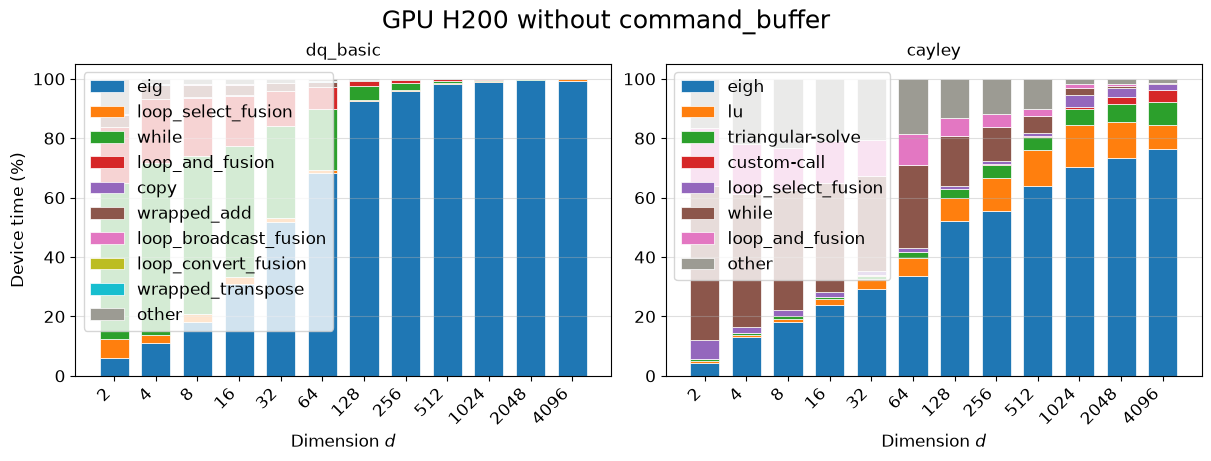

In [8]:
for device in devices:
    plot_breakdown(data[device], suptitle=f'{device.upper()}', normalize=True, top_n=10)

plot_breakdown(data['gpu_h200'], suptitle=f'GPU H200 without command_buffer', top_n=15, 
                without_command_buffer=True, normalize=True)